# Experiment: AKI Model Development and Evaluation

This notebook is organized to satisfy the model-development writeup requirements:

1. exploratory data analysis with tables and figures
2. data preprocessing for missingness and feature engineering
3. subject-level data splitting for model development
4. performance evaluation with AUROC, PR-AUC, and calibration curves for at least two models
5. interpretation of performance across models and splits


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET_COL = 'future_aki_24h'
ID_COLS = ['subject_id', 'hadm_id', 'stay_id']
TIME_COLS = [
    'icu_intime',
    'anchor_time',
    'obs_window_start',
    'obs_window_end',
    'pred_window_start',
    'pred_window_end',
]
LEAKAGE_COLS = [
    'hospital_expire_flag',
    'los_icu',
    'los_hospital',
    'icu_outtime',
    'dischtime',
    'aki_onset_time',
    'aki_onset_stage',
    'aki_stage_max',
    'has_aki_anytime',
    'eligible_for_prediction',
]
MISSINGNESS_THRESHOLD = 95.0
TEST_SIZE = 0.20
VAL_SIZE_WITHIN_DEV = 0.25
RANDOM_STATE = 42

CANDIDATE_INPUTS = [
    Path('outputs/mimic_aki_cohort_cleaned.csv'),
    Path('notebook/outputs/mimic_aki_cohort_cleaned.csv'),
    Path('../outputs/mimic_aki_cohort_cleaned.csv'),
    Path('/content/BIS568_Final_Project/notebook/outputs/mimic_aki_cohort_cleaned.csv'),
    Path('/content/BIS568_Final_Project/outputs/mimic_aki_cohort_cleaned.csv'),
]


def resolve_input_csv() -> Path:
    for candidate in CANDIDATE_INPUTS:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not locate mimic_aki_cohort_cleaned.csv in the expected outputs directories.')


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


INPUT_CSV = resolve_input_csv()
ARTIFACT_DIR = INPUT_CSV.parent / 'model_development_outputs'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print({'input_csv': str(INPUT_CSV), 'artifact_dir': str(ARTIFACT_DIR)})


{'input_csv': 'outputs/mimic_aki_cohort_cleaned.csv', 'artifact_dir': 'outputs/model_development_outputs'}


## Load cleaned dataset

The cleaned dataset should already preserve `subject_id`, `stay_id`, the target, and audit-friendly timing columns. The notebook starts by loading that file and applying a small set of clinically interpretable feature-engineering steps before model development.


In [2]:
df = pd.read_csv(INPUT_CSV)
for col in TIME_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if df[TARGET_COL].isna().any():
    df = df[df[TARGET_COL].notna()].copy()

df[TARGET_COL] = df[TARGET_COL].astype(int)


def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    engineered = frame.copy()

    if {'bun_last_6h', 'creatinine_last_6h'}.issubset(engineered.columns):
        engineered['bun_creatinine_ratio_last_6h'] = engineered['bun_last_6h'] / engineered['creatinine_last_6h'].replace(0, np.nan)

    if {'sbp_last_6h', 'dbp_last_6h'}.issubset(engineered.columns):
        engineered['pulse_pressure_last_6h'] = engineered['sbp_last_6h'] - engineered['dbp_last_6h']

    if {'heart_rate_last_6h', 'sbp_last_6h'}.issubset(engineered.columns):
        engineered['shock_index_last_6h'] = engineered['heart_rate_last_6h'] / engineered['sbp_last_6h'].replace(0, np.nan)

    if {'urine_total_6h', 'weight_used_for_uo_norm'}.issubset(engineered.columns):
        engineered['urine_ml_per_kg_6h'] = engineered['urine_total_6h'] / engineered['weight_used_for_uo_norm'].replace(0, np.nan)

    if {'creatinine_last_6h', 'creatinine_first_6h'}.issubset(engineered.columns):
        engineered['creatinine_change_6h'] = engineered['creatinine_last_6h'] - engineered['creatinine_first_6h']

    return engineered


df = add_engineered_features(df)
print(f'Dataset shape after loading and feature engineering: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print('Class balance:')
print(df[TARGET_COL].value_counts(dropna=False).sort_index())
print('Unique subjects:', df['subject_id'].nunique())
df.head()


Dataset shape after loading and feature engineering: 29,274 rows x 161 columns
Class balance:
future_aki_24h
0    12156
1    17118
Name: count, dtype: int64
Unique subjects: 29274


,subject_id,hadm_id,stay_id,icu_intime,anchor_time,obs_window_start,obs_window_end,pred_window_start,pred_window_end,future_aki_24h,...,urine_total_6h,urine_count_6h,weight_used_for_uo_norm,urine_rate_6h,oliguria_like_6h,bun_creatinine_ratio_last_6h,pulse_pressure_last_6h,shock_index_last_6h,urine_ml_per_kg_6h,creatinine_change_6h
0,10001725,25563031,31205490,2110-04-11 15:52:22,2110-04-11 21:52:22,2110-04-11 15:52:22,2110-04-11 21:52:22,2110-04-11 21:52:22,2110-04-12 21:52:22,0,...,300.0,1.0,72.2,0.692521,0.0,20.000000,27.0,0.772277,4.155125,0.0
1,10001884,26184834,37510196,2131-01-11 04:20:05,2131-01-11 10:20:05,2131-01-11 04:20:05,2131-01-11 10:20:05,2131-01-11 10:20:05,2131-01-12 10:20:05,0,...,625.0,4.0,65.0,1.602564,0.0,27.272727,50.0,0.603448,9.615385,0.0
2,10002013,23581541,39060235,2160-05-18 10:00:53,2160-05-18 16:00:53,2160-05-18 10:00:53,2160-05-18 16:00:53,2160-05-18 16:00:53,2160-05-19 16:00:53,1,...,280.0,3.0,96.0,0.486111,1.0,14.545455,56.0,0.744939,2.916667,0.0
3,10002155,23822395,33685454,2129-08-04 12:45:00,2129-08-04 18:45:00,2129-08-04 12:45:00,2129-08-04 18:45:00,2129-08-04 18:45:00,2129-08-05 18:45:00,1,...,250.0,1.0,53.0,0.786164,0.0,21.111111,53.0,0.647059,4.716981,0.0
4,10002348,22725460,32610785,2112-11-30 23:24:00,2112-12-01 05:24:00,2112-11-30 23:24:00,2112-12-01 05:24:00,2112-12-01 05:24:00,2112-12-02 05:24:00,0,...,50.0,1.0,41.6,0.200321,1.0,NaN,35.0,0.632653,1.201923,NaN


## 1. Exploratory data analysis

This section creates cohort summary tables and figures that can be reused in the project report. The goal is to understand the class balance, missingness pattern, and early physiologic differences between positive and negative AKI labels before model fitting.


In [3]:
cohort_summary = pd.DataFrame(
    {
        'metric': [
            'rows',
            'unique_subjects',
            'unique_stays',
            'positive_labels',
            'positive_rate_pct',
        ],
        'value': [
            len(df),
            df['subject_id'].nunique(),
            df['stay_id'].nunique(),
            int(df[TARGET_COL].sum()),
            round(df[TARGET_COL].mean() * 100, 2),
        ],
    }
)

key_eda_features = [
    col for col in [
        'admission_age',
        'creatinine_last_6h',
        'bun_last_6h',
        'urine_total_6h',
        'heart_rate_mean_6h',
        'mbp_mean_6h',
        'bun_creatinine_ratio_last_6h',
        'shock_index_last_6h',
    ]
    if col in df.columns
]

descriptive_table = (
    df.groupby(TARGET_COL)[key_eda_features]
      .agg(['median', 'mean'])
      .round(2)
      .T
)

display(cohort_summary)
display(descriptive_table)

cohort_summary.to_csv(ARTIFACT_DIR / 'cohort_summary.csv', index=False)
descriptive_table.to_csv(ARTIFACT_DIR / 'eda_feature_summary_by_target.csv')


,metric,value
0,rows,29274.00
1,unique_subjects,29274.00
2,unique_stays,29274.00
3,positive_labels,17118.00
4,positive_rate_pct,58.48


future_aki_24h                            0       1
admission_age                median   63.00   69.00
                             mean     61.48   67.22
creatinine_last_6h           median    0.80    0.90
                             mean      1.05    1.29
bun_last_6h                  median   16.00   19.00
                             mean     21.23   24.69
urine_total_6h               median  575.00  370.00
                             mean    716.83  494.70
heart_rate_mean_6h           median   82.75   82.86
                             mean     85.19   85.27
mbp_mean_6h                  median   80.86   78.57
                             mean     82.10   80.02
bun_creatinine_ratio_last_6h median   18.46   19.23
                             mean     20.67   21.06
shock_index_last_6h          median    0.70    0.71
                             mean      0.73    0.74

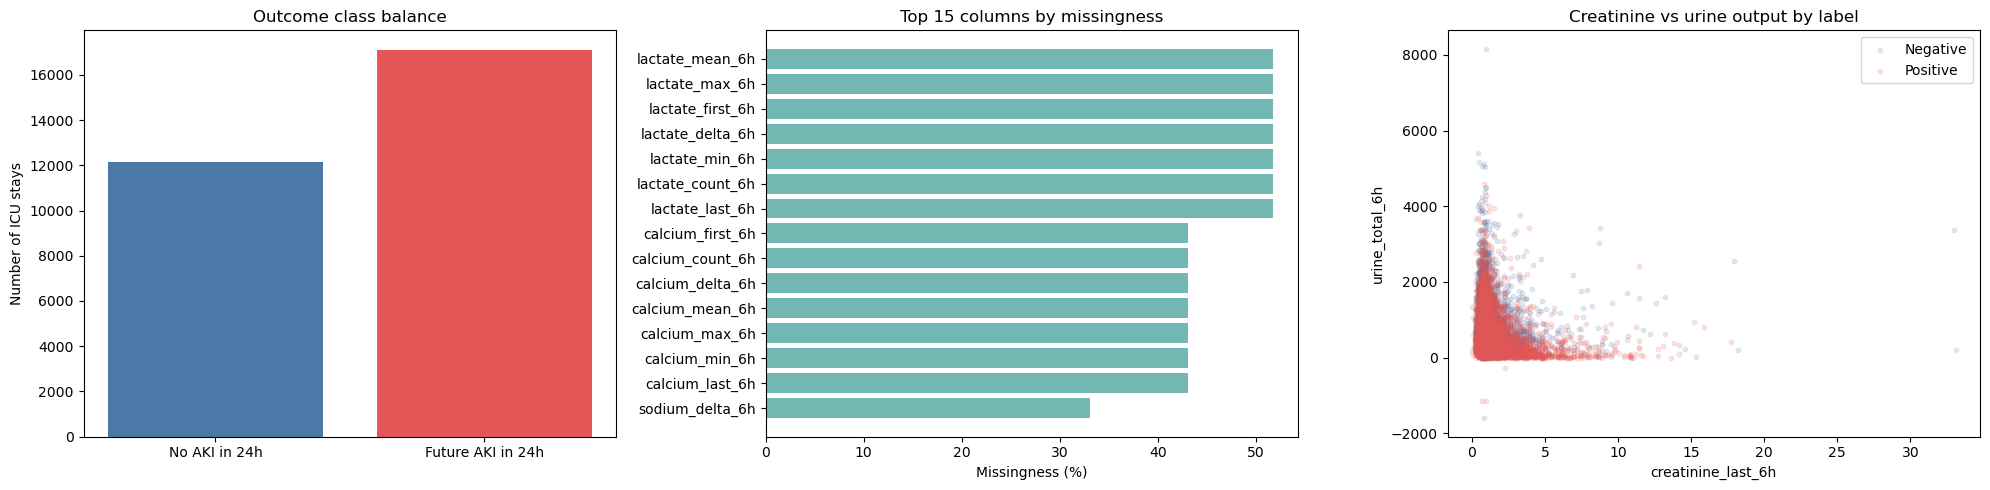

In [4]:
missingness = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename('missing_pct')
      .reset_index()
      .rename(columns={'index': 'column'})
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

label_counts = df[TARGET_COL].value_counts().sort_index()
axes[0].bar(['No AKI in 24h', 'Future AKI in 24h'], label_counts.values, color=['#4C78A8', '#E45756'])
axes[0].set_title('Outcome class balance')
axes[0].set_ylabel('Number of ICU stays')

missing_plot = missingness.head(15).sort_values('missing_pct')
axes[1].barh(missing_plot['column'], missing_plot['missing_pct'], color='#72B7B2')
axes[1].set_title('Top 15 columns by missingness')
axes[1].set_xlabel('Missingness (%)')

plot_cols = [col for col in ['creatinine_last_6h', 'urine_total_6h'] if col in df.columns]
if len(plot_cols) == 2:
    positive = df[df[TARGET_COL] == 1]
    negative = df[df[TARGET_COL] == 0]
    axes[2].scatter(
        negative[plot_cols[0]],
        negative[plot_cols[1]],
        alpha=0.15,
        s=10,
        label='Negative',
        color='#4C78A8',
    )
    axes[2].scatter(
        positive[plot_cols[0]],
        positive[plot_cols[1]],
        alpha=0.15,
        s=10,
        label='Positive',
        color='#E45756',
    )
    axes[2].set_xlabel(plot_cols[0])
    axes[2].set_ylabel(plot_cols[1])
    axes[2].set_title('Creatinine vs urine output by label')
    axes[2].legend()
else:
    axes[2].axis('off')
    axes[2].text(0.1, 0.5, 'Feature scatter skipped because required columns are missing.', fontsize=11)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'eda_overview.png', dpi=200, bbox_inches='tight')
plt.show()


## 2. Data preprocessing for missingness and feature engineering

The preprocessing strategy is intentionally simple and reportable:

- engineered a small set of clinically interpretable ratio / difference features
- removed features with extremely high missingness or no variation
- excluded identifiers, timing columns, and explicit leakage columns from the model matrix
- imputed numeric variables with the median and categorical variables with the most frequent category
- standardized numeric variables for logistic regression


In [5]:
required_keep_cols = set(ID_COLS + TIME_COLS + [TARGET_COL])
leakage_cols_present = [col for col in LEAKAGE_COLS if col in df.columns]
missing_pct = df.isna().mean().mul(100)

high_missing_cols = [
    col for col, pct in missing_pct.items()
    if pct >= MISSINGNESS_THRESHOLD and col not in required_keep_cols
]
constant_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1 and col not in required_keep_cols
]

excluded_feature_cols = sorted(set(ID_COLS + TIME_COLS + leakage_cols_present + high_missing_cols + constant_cols + [TARGET_COL]))
feature_cols = [col for col in df.columns if col not in excluded_feature_cols]

preprocessing_summary = pd.DataFrame(
    {
        'step': [
            'engineered_features_added',
            'high_missing_columns_removed',
            'constant_columns_removed',
            'explicit_leakage_columns_removed',
            'final_feature_count',
        ],
        'count': [
            len(set(df.columns) - set(pd.read_csv(INPUT_CSV, nrows=1).columns)),
            len(high_missing_cols),
            len(constant_cols),
            len(leakage_cols_present),
            len(feature_cols),
        ],
    }
)

display(preprocessing_summary)
print('Removed for high missingness:', high_missing_cols)
print('Removed as constants:', constant_cols)
print('Removed as explicit leakage columns:', leakage_cols_present)
print('First 20 modeling features:', feature_cols[:20])

preprocessing_summary.to_csv(ARTIFACT_DIR / 'preprocessing_summary.csv', index=False)


,step,count
0,engineered_features_added,5
1,high_missing_columns_removed,0
2,constant_columns_removed,0
3,explicit_leakage_columns_removed,0
4,final_feature_count,151


Removed for high missingness: []
Removed as constants: []
Removed as explicit leakage columns: []
First 20 modeling features: ['admission_age', 'gender', 'race', 'admission_type', 'admission_location', 'insurance', 'language', 'marital_status', 'ckd_flag', 'diabetes_flag', 'hypertension_flag', 'chf_flag', 'liver_disease_flag', 'sepsis_infection_flag', 'chronic_pulmonary_flag', 'creatinine_first_6h', 'creatinine_last_6h', 'creatinine_min_6h', 'creatinine_max_6h', 'creatinine_mean_6h']


## 3. Subject-level data splitting for model development

Rows from the same patient must never appear in both train and evaluation data. This notebook uses a two-stage `GroupShuffleSplit`:

- first split: development vs. held-out test set
- second split: training vs. validation within the development set

The grouping variable is always `subject_id`.


In [6]:
groups = df['subject_id']
outer_split = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
dev_idx, test_idx = next(outer_split.split(df, df[TARGET_COL], groups=groups))

dev_df = df.iloc[dev_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

inner_split = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE_WITHIN_DEV, random_state=RANDOM_STATE)
train_idx, val_idx = next(inner_split.split(dev_df, dev_df[TARGET_COL], groups=dev_df['subject_id']))

train_df = dev_df.iloc[train_idx].reset_index(drop=True)
val_df = dev_df.iloc[val_idx].reset_index(drop=True)

split_summary = pd.DataFrame(
    {
        'split': ['train', 'validation', 'test'],
        'rows': [len(train_df), len(val_df), len(test_df)],
        'unique_subjects': [
            train_df['subject_id'].nunique(),
            val_df['subject_id'].nunique(),
            test_df['subject_id'].nunique(),
        ],
        'positive_rate_pct': [
            round(train_df[TARGET_COL].mean() * 100, 2),
            round(val_df[TARGET_COL].mean() * 100, 2),
            round(test_df[TARGET_COL].mean() * 100, 2),
        ],
    }
)

display(split_summary)
print('Overlap train/validation:', len(set(train_df['subject_id']).intersection(set(val_df['subject_id']))))
print('Overlap train/test:', len(set(train_df['subject_id']).intersection(set(test_df['subject_id']))))
print('Overlap validation/test:', len(set(val_df['subject_id']).intersection(set(test_df['subject_id']))))

split_summary.to_csv(ARTIFACT_DIR / 'split_summary.csv', index=False)


,split,rows,unique_subjects,positive_rate_pct
0,train,17564,17564,58.41
1,validation,5855,5855,58.70
2,test,5855,5855,58.45


Overlap train/validation: 0
Overlap train/test: 0
Overlap validation/test: 0


## 4. Model fitting setup

Two models are developed on the same feature set:

- **Logistic regression**: a linear baseline with standardized numeric features
- **Random forest**: a nonlinear tree-based baseline with the same train / validation / test split

This keeps the comparison focused on architecture rather than changing the data definition.


In [7]:
train_X = train_df[feature_cols].copy()
val_X = val_df[feature_cols].copy()
test_X = test_df[feature_cols].copy()
train_y = train_df[TARGET_COL].astype(int)
val_y = val_df[TARGET_COL].astype(int)
test_y = test_df[TARGET_COL].astype(int)

numeric_cols = train_X.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_cols = [col for col in feature_cols if col not in numeric_cols]

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            numeric_cols,
        ),
        (
            'categorical',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', make_one_hot_encoder()),
            ]),
            categorical_cols,
        ),
    ],
    remainder='drop',
)

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
            ]),
            numeric_cols,
        ),
        (
            'categorical',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', make_one_hot_encoder()),
            ]),
            categorical_cols,
        ),
    ],
    remainder='drop',
)

models = {
    'Logistic Regression': Pipeline([
        ('preprocess', logistic_preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced')),
    ]),
    'Random Forest': Pipeline([
        ('preprocess', rf_preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight='balanced_subsample',
        )),
    ]),
}

print({'numeric_features': len(numeric_cols), 'categorical_features': len(categorical_cols)})


{'numeric_features': 144, 'categorical_features': 7}


## 5. Model development and evaluation metrics

Each model is trained on the training split and then evaluated on both the validation split and the held-out test split. The core metrics are:

- AUROC
- PR-AUC
- Brier score (added as a compact calibration summary)

Calibration curves are plotted separately in the next section.


In [8]:
def evaluate_predictions(y_true: pd.Series, proba: np.ndarray) -> dict[str, float]:
    return {
        'auroc': roc_auc_score(y_true, proba),
        'pr_auc': average_precision_score(y_true, proba),
        'brier_score': brier_score_loss(y_true, proba),
    }


results = []
prediction_store: dict[str, dict[str, np.ndarray]] = {}

for model_name, pipeline in models.items():
    fitted = clone(pipeline)
    fitted.fit(train_X, train_y)
    prediction_store[model_name] = {}

    for split_name, X_split, y_split in [
        ('validation', val_X, val_y),
        ('test', test_X, test_y),
    ]:
        proba = fitted.predict_proba(X_split)[:, 1]
        prediction_store[model_name][split_name] = proba
        metrics = evaluate_predictions(y_split, proba)
        results.append(
            {
                'model': model_name,
                'split': split_name,
                **metrics,
            }
        )

metrics_df = pd.DataFrame(results).sort_values(['split', 'pr_auc'], ascending=[True, False])
display(metrics_df)
metrics_df.to_csv(ARTIFACT_DIR / 'model_metrics.csv', index=False)


,model,split,auroc,pr_auc,brier_score
3,Random Forest,test,0.727285,0.796118,0.205965
1,Logistic Regression,test,0.727904,0.791459,0.210457
0,Logistic Regression,validation,0.740109,0.801460,0.205867
2,Random Forest,validation,0.727601,0.792444,0.206006


## 6. Performance figures: ROC, PR, and calibration curves

These figures are the main model-evaluation visuals for the report. They show both model comparison and split comparison using the same outcome definition and subject-level split strategy.


In [ ]:
def plot_roc(ax, y_true: pd.Series, prediction_map: dict[str, np.ndarray], split_name: str) -> None:
    from sklearn.metrics import roc_curve

    for model_name, proba in prediction_map.items():
        fpr, tpr, _ = roc_curve(y_true, proba)
        auroc = roc_auc_score(y_true, proba)
        ax.plot(fpr, tpr, label=f'{model_name} (AUC={auroc:.3f})')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(f'ROC curves: {split_name}')
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.legend()


def plot_pr(ax, y_true: pd.Series, prediction_map: dict[str, np.ndarray], split_name: str) -> None:
    from sklearn.metrics import precision_recall_curve

    prevalence = y_true.mean()
    for model_name, proba in prediction_map.items():
        precision, recall, _ = precision_recall_curve(y_true, proba)
        pr_auc = average_precision_score(y_true, proba)
        ax.plot(recall, precision, label=f'{model_name} (PR-AUC={pr_auc:.3f})')
    ax.axhline(prevalence, linestyle='--', color='gray', label=f'Prevalence={prevalence:.3f}')
    ax.set_title(f'Precision-recall curves: {split_name}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()


def plot_calibration(ax, y_true: pd.Series, prediction_map: dict[str, np.ndarray], split_name: str) -> None:
    for model_name, proba in prediction_map.items():
        frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy='quantile')
        ax.plot(mean_pred, frac_pos, marker='o', label=model_name)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    ax.set_title(f'Calibration curve: {split_name}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed event rate')
    ax.legend()


validation_preds = {model: prediction_store[model]['validation'] for model in prediction_store}
test_preds = {model: prediction_store[model]['test'] for model in prediction_store}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_roc(axes[0, 0], val_y, validation_preds, 'validation')
plot_pr(axes[0, 1], val_y, validation_preds, 'validation')
plot_calibration(axes[0, 2], val_y, validation_preds, 'validation')
plot_roc(axes[1, 0], test_y, test_preds, 'test')
plot_pr(axes[1, 1], test_y, test_preds, 'test')
plot_calibration(axes[1, 2], test_y, test_preds, 'test')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'roc_pr_calibration_curves.png', dpi=200, bbox_inches='tight')
plt.show()


## 7. Interpretation of model performance and comparison between splits and models

The final cell generates a short text summary that can be adapted into the project report. It compares the best-performing model on the held-out test set, comments on validation-to-test performance shifts, and highlights the calibration tradeoff.


In [ ]:
def plot_roc(ax, y_true: pd.Series, prediction_map: dict[str, np.ndarray], split_name: str) -> None:
    from sklearn.metrics import roc_curve

    for model_name, proba in prediction_map.items():
        fpr, tpr, _ = roc_curve(y_true, proba)
        auroc = roc_auc_score(y_true, proba)
        ax.plot(fpr, tpr, label=f'{model_name} (AUC={auroc:.3f})')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(f'ROC Curve - {split_name}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()


def plot_pr(ax, y_true: pd.Series, prediction_map: dict[str, np.ndarray], split_name: str) -> None:
    from sklearn.metrics import precision_recall_curve

    prevalence = y_true.mean()
    for model_name, proba in prediction_map.items():
        precision, recall, _ = precision_recall_curve(y_true, proba)
        pr_auc = average_precision_score(y_true, proba)
        ax.plot(recall, precision, label=f'{model_name} (PR-AUC={pr_auc:.3f})')
    ax.axhline(prevalence, linestyle='--', color='gray', label=f'Prevalence={prevalence:.3f}')
    ax.set_title(f'Precision-Recall Curve - {split_name}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()


def plot_calibration(ax, y_true: pd.Series, prediction_map: dict[str, np.ndarray], split_name: str) -> None:
    for model_name, proba in prediction_map.items():
        frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy='quantile')
        ax.plot(mean_pred, frac_pos, marker='o', label=model_name)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    ax.set_title(f'Calibration Curve - {split_name}')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Observed Event Rate')
    ax.legend()


validation_preds = {model: prediction_store[model]['validation'] for model in prediction_store}
test_preds = {model: prediction_store[model]['test'] for model in prediction_store}

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
plot_roc(axes[0, 0], val_y, validation_preds, 'Validation Set')
plot_roc(axes[0, 1], test_y, test_preds, 'Test Set')
plot_pr(axes[1, 0], val_y, validation_preds, 'Validation Set')
plot_pr(axes[1, 1], test_y, test_preds, 'Test Set')
plot_calibration(axes[2, 0], val_y, validation_preds, 'Validation Set')
plot_calibration(axes[2, 1], test_y, test_preds, 'Test Set')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'roc_pr_calibration_curves_grouped.png', dpi=200, bbox_inches='tight')
plt.show()


In [12]:
summary_rows = []
for model_name in metrics_df['model'].unique():
    val_row = metrics_df[(metrics_df['model'] == model_name) & (metrics_df['split'] == 'validation')].iloc[0]
    test_row = metrics_df[(metrics_df['model'] == model_name) & (metrics_df['split'] == 'test')].iloc[0]
    summary_rows.append(
        {
            'model': model_name,
            'validation_auroc': val_row['auroc'],
            'test_auroc': test_row['auroc'],
            'validation_pr_auc': val_row['pr_auc'],
            'test_pr_auc': test_row['pr_auc'],
            'validation_brier': val_row['brier_score'],
            'test_brier': test_row['brier_score'],
            'pr_auc_gap_val_to_test': test_row['pr_auc'] - val_row['pr_auc'],
        }
    )

comparison_df = pd.DataFrame(summary_rows).sort_values('test_pr_auc', ascending=False)
display(comparison_df)
comparison_df.to_csv(ARTIFACT_DIR / 'model_comparison_summary.csv', index=False)

best_model = comparison_df.iloc[0]
most_stable = comparison_df.iloc[comparison_df['pr_auc_gap_val_to_test'].abs().argmin()]

interpretation_lines = [
    f"Best held-out test PR-AUC: {best_model['model']} ({best_model['test_pr_auc']:.3f}).",
    f"Best held-out test AUROC: {comparison_df.sort_values('test_auroc', ascending=False).iloc[0]['model']} ({comparison_df['test_auroc'].max():.3f}).",
    f"Most stable validation-to-test PR-AUC gap: {most_stable['model']} ({most_stable['pr_auc_gap_val_to_test']:+.3f}).",
]

for model_name in comparison_df['model']:
    row = comparison_df[comparison_df['model'] == model_name].iloc[0]
    interpretation_lines.append(
        f"{model_name}: validation/test AUROC = {row['validation_auroc']:.3f}/{row['test_auroc']:.3f}, "
        f"validation/test PR-AUC = {row['validation_pr_auc']:.3f}/{row['test_pr_auc']:.3f}, "
        f"validation/test Brier = {row['validation_brier']:.3f}/{row['test_brier']:.3f}."
    )

print(''.join(interpretation_lines))


,model,validation_auroc,test_auroc,validation_pr_auc,test_pr_auc,validation_brier,test_brier,pr_auc_gap_val_to_test
0,Random Forest,0.727601,0.727285,0.792444,0.796118,0.206006,0.205965,0.003674
1,Logistic Regression,0.740109,0.727904,0.801460,0.791459,0.205867,0.210457,-0.010001


Best held-out test PR-AUC: Random Forest (0.796).Best held-out test AUROC: Logistic Regression (0.728).Most stable validation-to-test PR-AUC gap: Random Forest (+0.004).Random Forest: validation/test AUROC = 0.728/0.727, validation/test PR-AUC = 0.792/0.796, validation/test Brier = 0.206/0.206.Logistic Regression: validation/test AUROC = 0.740/0.728, validation/test PR-AUC = 0.801/0.791, validation/test Brier = 0.206/0.210.


## Report-ready notes

When you write the project report, keep the interpretation tied to these outputs:

- use the EDA tables / figures to motivate data quality and class imbalance
- describe the missingness threshold, imputation rules, and engineered features in the preprocessing section
- report that the split was performed by `subject_id`, not by row
- cite the AUROC, PR-AUC, and calibration plots from the held-out test set when comparing models
- explain any validation-to-test drop as potential overfitting or split sensitivity rather than claiming generalization too aggressively
